# T3.5 Recursión versus iteración

## 1. Comparativa entre recursión e iteración

Vamos a comparar diferentes aspectos de la recursión y la iteración como estrategias de resolución de problemas mediante repetición.

A continuación tenemos las implementaciones iterativa y recursiva de factorial, respectivamente:

In [1]:
# Comparación final: factorial iterativo versus recursivo.

def factorial_iterativo(n):
    resultado = 1
    i = 1
    while i <= n:
        resultado *= i
        i += 1
    return resultado

def factorial_recursivo(n):
    if n == 0:
        return 1
    else:
        return n * factorial_recursivo(n - 1)

n = 10
print(f'{n}! iterativo: {factorial_iterativo(n)}')
print(f'{n}! recursivo: {factorial_recursivo(n)}')

10! iterativo: 3628800
10! recursivo: 3628800


* **Estructuras de control**: 
  + La **recursión** usa de base `if/else`, 
  + La **iteración** usa esquemas explícitos de repetición (`while`, `for`).
* **Condición de terminación**:
  + La **recursión** usa la condición del caso base.
    + Si no se llega a alcanzar el caso base, se alcanza el límite de recursión (Python con `RecursionError`, Java con `StackOverflowError`) o provoca una violación de segmento (C/C++).
  + La **iteración** usa la condición de la guarda del bucle correspondiente.
    + Si la guarda del bucle nunca se evalua a falso, el algoritmo incurre en un bucle infinito (nunca termina).
* **Aproximación gradual a la terminación**: 
  + La **recursión** se aproxima conforme se divide el problema en otros más pequeños, acercándose también al cumplimiento de la condición del caso base.
  + La **iteración** se aproxima a medida que se acerca al cumplimiento de la condición de guarda.
* **Equivalencia algorítmitca**:
  + Se puede demostrar que la solución algorítmica de cualquier problema algorítmicamente resoluble, se puede expresar tanto recursivamente como iterativamente.
  + En este sentido, se dice que recursión e iteración son equivalentes, y por eso, alternativos.
* **Eficiencia computacional**:
  + La solución recursiva consume significativamente más memoria que la solución iterativa, debido al uso intensivo de la pila de llamadas.
  + La solución recursiva es ligeramente más lenta que la iterativa, debido a la gestión de los registros de activación y los sucesivos cambios de contexto durante el flujo de ejecución.

### Medición de rendimiento (tiempo y memoria)

Para comparar cuantitativamente ambas aproximaciones, vamos a medir el tiempo de ejecución (usando `timeit`) y el consumo de memoria pico (usando `tracemalloc`). 

Observa cómo la recursión, al requerir la creación de marcos de activación en la pila para cada llamada, consume significativamente más memoria que la iteración.

In [2]:
import timeit
import tracemalloc
import sys
import gc

def medir_tiempo(f, n, repeticiones=1000):
    tiempo_total_seg = timeit.timeit(lambda: f(n), number=repeticiones)
    tiempo_medio_miliseg = tiempo_total_seg * 1e4 / repeticiones
    return tiempo_medio_miliseg

def medir_pico_consumo_memoria(f, n):
    gc.collect()  # Llamamos al garbage collector para limpiar el heap.
    tracemalloc.start()
    f(n)
    _, pico_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return pico_mem

n = 500
print(f"Comparando rendimiento para factorial({n}):\n")

# Medición iterativa
t_iter = medir_tiempo(factorial_iterativo, n)
m_iter = medir_pico_consumo_memoria(factorial_iterativo, n)
print(f"[ITERATIVO]\n  Tiempo medio: {t_iter:.1f} ms\n  Consumo máximo de memoria: {m_iter/2**10:.1f} Kb")

# Medición recursiva
t_rec = medir_tiempo(factorial_recursivo, n)
m_rec = medir_pico_consumo_memoria(factorial_recursivo, n)
print(f"\n[RECURSIVO]\n  Tiempo medio: {t_rec:.1f} ms\n  Consumo máximo de memoria: {m_rec/2**10:.1f} Kb")

print(f"\nRelación de tiempo (recursivo/iterativo): {t_rec / t_iter:.1f} veces más lento")
print(f"Relación de memoria (recursivo/iterativo): {m_rec / m_iter:.1f} veces más costoso")

Comparando rendimiento para factorial(500):

[ITERATIVO]
  Tiempo medio: 1.0 ms
  Consumo máximo de memoria: 1.1 Kb

[RECURSIVO]
  Tiempo medio: 1.4 ms
  Consumo máximo de memoria: 8.1 Kb

Relación de tiempo (recursivo/iterativo): 1.5 veces más lento
Relación de memoria (recursivo/iterativo): 7.6 veces más costoso


### Representación gráfica del consumo de memoria

A continuación, generamos una gráfica que compara el pico de consumo de memoria (en Kb) entre ambas implementaciones para diferentes valores de `n` con `factorial(n)`.

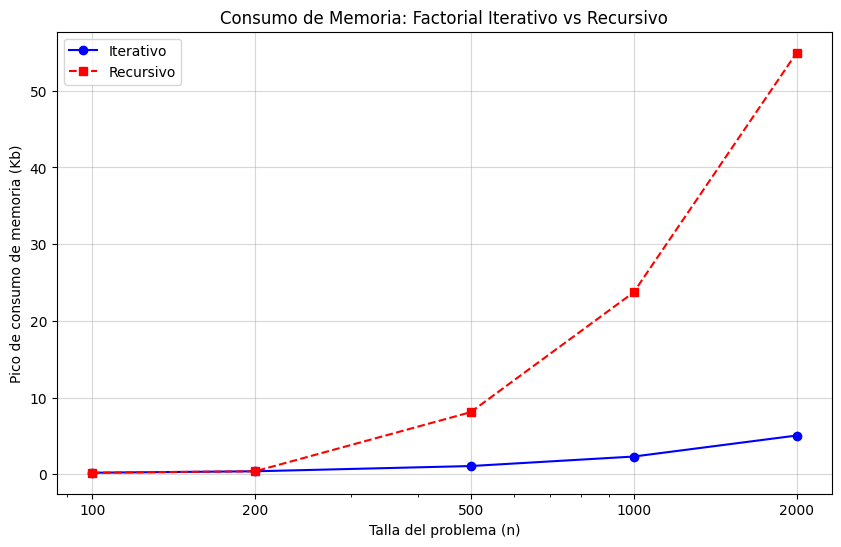

In [3]:
import matplotlib.pyplot as plt
import sys

sys.setrecursionlimit(3000)

n_values = [100, 200, 500, 1000, 2000]
mem_iter = []; mem_rec = []

for n in n_values:
    mem_iter.append(medir_pico_consumo_memoria(factorial_iterativo, n) / 1024) # Kb
    mem_rec.append(medir_pico_consumo_memoria(factorial_recursivo, n) / 1024)   # Kb

plt.figure(figsize=(10, 6))
plt.plot(n_values, mem_iter, label='Iterativo', marker='o', linestyle='-', color='blue')
plt.plot(n_values, mem_rec, label='Recursivo', marker='s', linestyle='--', color='red')

plt.title('Consumo de Memoria: Factorial Iterativo vs Recursivo')
plt.xlabel('Talla del problema (n)')
plt.ylabel('Pico de consumo de memoria (Kb)')
plt.legend()
plt.grid(True, which="major", ls="-", alpha=0.5)
plt.xscale('log')  
plt.xticks(n_values, n_values)
plt.show()

## 2. ¿Qué es más conveniente?

No hay una respuesta universal para todos los casos. 

Es frecuente encontrar problemas para los cuales la solución iterativa es más sencilla de estructurar que la recursiva.
  + Resulta más natural aplicar algoritmos iterativos para procesar estructuras de datos lineales (secuencias).

No obstante, hay casos en los que la versión recursiva refleja de manera más natural, concisa y elegante, la solución al problema que la versión iterativa. Esto hace que el código sea más fácil de depurar y entender. 
  + Los problemas de naturaleza puramente recursiva (factorial, fibonacci, búsqueda binaria) se transcriben en formato recursivo de forma trivial. 
  + Resulta muy natural aplicar algoritmos recursivos para operar con estructuras de datos de naturaleza recursiva (p.e. árboles binarios de búsqueda).
  
La recursión supone, en general, un mayor coste computacional (espacio en memoria) que la iteración, debido al uso intensivo de la pila. 
  + Notar que el sobrecoste de memoria escala (empeora) con la talla del problema (esto lo estudiaremos en el próximo tema!).

Se puede concluir que recursión e iteración son alternativos y complementarios.

**Recomendación general**: apostaremos por algoritmos recursivos cuando sean la solución algorítmica más natural, legible y mantenible; siempre y cuando el sobrecoste computacional asociado a la recursión (memoria) sea asumible.